## 0. Librerías

In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import os
from openai import OpenAI
import re
from pathlib import Path
import importlib.util
from typing import Optional
import sys

## 1. Ingesta de datos

In [202]:
DROPBOX_URL = "https://www.dropbox.com/scl/fi/7ppbz8717q1xr6zap1y55/df_final.csv?rlkey=0qwrigm434he3jbigcct01xch&e=1&st=hvwhzc3h&dl=1"


df = pd.read_csv(
    DROPBOX_URL,
    sep=",",
    engine="python",
    encoding="latin1",
    on_bad_lines="warn"
   )




In [203]:
print(df.columns.tolist())


['id', 'occurrenceID', 'catalogNumber', 'basisOfRecord', 'collectionCode', 'dynamicProperties', 'otherCatalogNumbers', 'genus', 'specificEpithet', 'infraspecificEpithet', 'scientificName', 'taxonRank', 'kingdom', 'family', 'higherClassification', 'nomenclaturalCode', 'identificationRemarks', 'vernacularName', 'longitudeDecimal', 'latitudeDecimal', 'geodeticDatum', 'country', 'locality', 'verbatimElevation', 'recordedBy', 'eventDate', 'eventTime', 'verbatimEventDate', 'fieldNotes', 'behavior', 'sex', 'lifeStage', 'preparations', 'references', 'Associated Taxa', 'rightsHolder_x', 'license_x', 'CoreId', 'associatedObservationReference', 'Identifier', 'type', 'Rating', 'rightsHolder_y', 'creator', 'accessURI', 'format', 'variantLiteral', 'description', 'caption', 'resourceCreationTechnique', 'captureDevice', 'physicalSetting', 'license_y']


## 2. Auditoría de datos y configuración

In [204]:
def audit_dataframe(df: pd.DataFrame, audio_col: str = "Identifier") -> dict:
    info = {
        "rows": len(df),
        "cols": df.shape[1],
        "memory_mb": round(df.memory_usage(deep=True).sum() / 1024**2, 2),
        "duplicates_audio": int(df.duplicated(subset=[audio_col]).sum()),
        "unique_audios": df[audio_col].nunique(),
        "nulls_pct": (df.isnull().mean() * 100).round(2).sort_values(ascending=False).to_dict(),
        "dtypes": df.dtypes.astype(str).to_dict(),
    }
    return info

audit = audit_dataframe(df)
audit


{'rows': 160443,
 'cols': 53,
 'memory_mb': np.float64(571.38),
 'duplicates_audio': 52,
 'unique_audios': 160391,
 'nulls_pct': {'caption': 100.0,
  'otherCatalogNumbers': 99.84,
  'identificationRemarks': 99.69,
  'infraspecificEpithet': 98.78,
  'dynamicProperties': 73.81,
  'captureDevice': 73.8,
  'lifeStage': 70.39,
  'Associated Taxa': 69.22,
  'sex': 67.09,
  'fieldNotes': 4.6,
  'eventTime': 4.08,
  'longitudeDecimal': 1.39,
  'geodeticDatum': 1.38,
  'latitudeDecimal': 1.38,
  'behavior': 1.25,
  'Rating': 0.77,
  'eventDate': 0.17,
  'description': 0.01,
  'preparations': 0.01,
  'locality': 0.01,
  'physicalSetting': 0.01,
  'vernacularName': 0.0,
  'family': 0.0,
  'higherClassification': 0.0,
  'nomenclaturalCode': 0.0,
  'specificEpithet': 0.0,
  'scientificName': 0.0,
  'taxonRank': 0.0,
  'kingdom': 0.0,
  'genus': 0.0,
  'catalogNumber': 0.0,
  'basisOfRecord': 0.0,
  'id': 0.0,
  'occurrenceID': 0.0,
  'collectionCode': 0.0,
  'verbatimElevation': 0.0,
  'country': 0

Hemos confirmado la ausencia de duplicados y formatos de audio únicos. A continuación identificamos los nombres científicos únicos del dataset y el volumen de cada uno

In [205]:
df['scientificName'].unique()

array(['Parus major', 'Spinus spinus', 'Haematopus ostralegus',
       'Phylloscopus collybita', 'Turdus philomelos', 'Rallus aquaticus',
       'Mystery mystery', 'Phoenicurus ochruros', 'Numenius phaeopus',
       'Regulus ignicapilla', 'Cyanistes caeruleus', 'Muscicapa striata',
       'Phylloscopus trochilus', 'Gallinula chloropus',
       'Actitis hypoleucos', 'Cuculus canorus', 'Cettia cetti',
       'Emberiza schoeniclus', 'Coturnix coturnix',
       'Tachybaptus ruficollis', 'Aegithalos caudatus',
       'Gallinago gallinago', 'Sturnus vulgaris', 'Motacilla alba',
       'Acrocephalus scirpaceus', 'Troglodytes troglodytes',
       'Loxia curvirostra', 'Acrocephalus arundinaceus',
       'Passer domesticus', 'Oriolus oriolus', 'Anas platyrhynchos',
       'Acrocephalus palustris', 'Turdus iliacus', 'Hippolais icterina',
       'Numenius arquata', 'Charadrius dubius', 'Anas crecca',
       'Sylvia atricapilla', 'Fringilla coelebs', 'Ficedula hypoleuca',
       'Luscinia megarhync

In [206]:
# Volumen de registros por especie
pd.set_option('display.max_rows', None)
df['scientificName'].value_counts()


scientificName
Mystery mystery                  15059
Parus major                       4269
Turdus merula                     4216
Erithacus rubecula                3978
Fringilla coelebs                 3595
Sylvia atricapilla                3303
Turdus philomelos                 3254
Phylloscopus collybita            3200
Troglodytes troglodytes           2668
Strix aluco                       2391
Rallus aquaticus                  2320
Cyanistes caeruleus               2249
Turdus iliacus                    2104
Gallinula chloropus               2027
Emberiza citrinella               1966
Dendrocopos major                 1865
Fulica atra                       1858
Loxia curvirostra                 1762
Luscinia megarhynchos             1731
Alauda arvensis                   1726
Anthus trivialis                  1712
Phylloscopus trochilus            1682
Emberiza calandra                 1675
Curruca communis                  1647
Actitis hypoleucos                1645
Prunella m

In [207]:
df['scientificName'].nunique()
#Son 180 especies

105

In [208]:
# Configuraciones y constantes
MIN_SAMPLES_PER_SPECIES = 600
CAP_SAMPLES_PER_SPECIES = 900
RANDOM_SEED = 42

CANDIDATE_LABEL_COLS = ["scientificName", "species", "label"]
CANDIDATE_AUDIO_COLS = ["OcurrenceID", "audio_url", "soundUrl", "accessURI","identifier", "url", "audio", "media_url"]
CANDIDATE_COUNTRY_COLS = ["country", "countryCode", "country_code"]
META_COLS = ["vernacularName", "family", "behavior", "description"]  
label_key = "scientificName"

INVALID_LABEL_PATTERNS = [
    r"^\s*$",
    r"^mystery\s*$",
    r"^unknown\s*$",
    r"^unidentified\s*$",
    r"^sp\.\s*$",
]

# Ampliamos el conjunto de extensiones de audio permitidas
ALLOWED_AUDIO_EXT = {"mp3", "wav", "flac", "ogg", "wma", "m4a"}

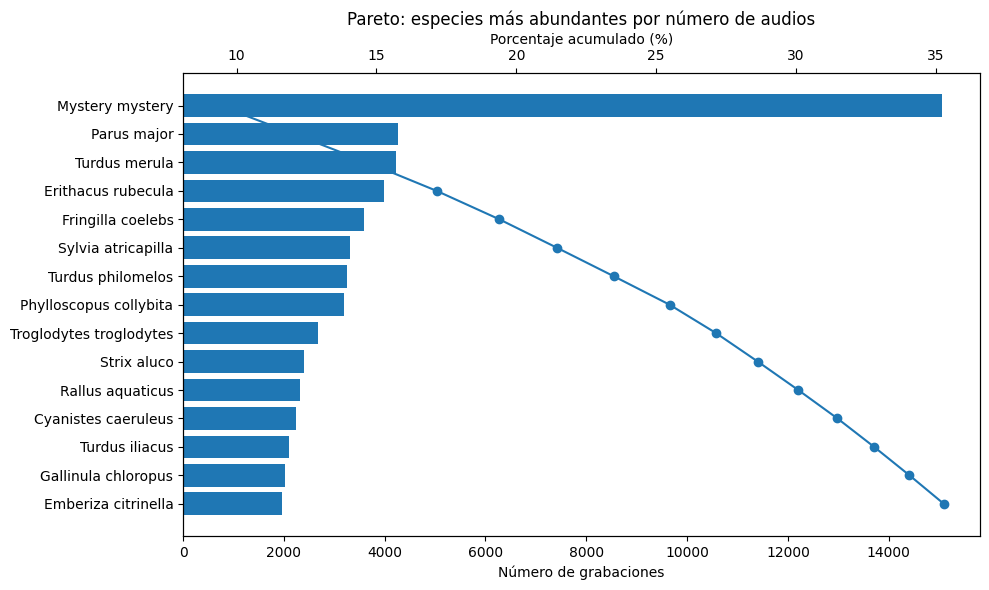

In [209]:
top_n = 15

df_pareto = (
    df.groupby("scientificName")
      .size()
      .reset_index(name="n_audios")
      .sort_values("n_audios", ascending=False)
)

# Porcentaje acumulado
df_pareto["cum_pct"] = df_pareto["n_audios"].cumsum() / df_pareto["n_audios"].sum() * 100


df_top = df_pareto.head(top_n)

# Gráfico de Pareto
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.barh(
    df_top["scientificName"][::-1],
    df_top["n_audios"][::-1]
)
ax1.set_xlabel("Número de grabaciones")
ax1.set_title("Pareto: especies más abundantes por número de audios")

ax2 = ax1.twiny()
ax2.plot(
    df_top["cum_pct"][::-1],
    df_top["scientificName"][::-1],
    marker="o"
)
ax2.set_xlabel("Porcentaje acumulado (%)")

plt.tight_layout()
plt.show()




El análisis de Pareto muestra una distribución altamente asimétrica del número de grabaciones por especie, con una concentración significativa en un subconjunto reducido de clases. Este desbalance justifica la aplicación de técnicas de balanceo previo al entrenamiento para evitar sesgos del modelo hacia las especies mayoritarias. Hay una concentración muy fuerte de audios en pocas especies. Las primeras 5–6 especies ya explican una parte relevante del volumen total, mientras que el resto entra claramente en cola larga. La categoría "Mystery mystery" ha de ser excluida del dataset final ya que es una alerta de la calidad del dataset. Pueden ser audios mal etiquetados o bien mal filtrados, pero afectarían al entrenamiento negativamente

### 3. Helpers

In [210]:
# Devuelve el nombre de la primera columna existente en el DataFrame de la lista de candidatos (si no, lanza error)
def pick_col(df: pd.DataFrame, candidates: list[str]) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"No se encontró ninguna de estas columnas: {candidates}")

# Normaliza el texto: convierte a str, quita espacios extras
def normalize_text(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

# Verifica si una etiqueta es inválida
def is_invalid_label(x: str) -> bool:
    xl = (x or "").strip().lower()
    return any(re.match(p, xl) for p in INVALID_LABEL_PATTERNS)

# Extrae la extensión de audio de la URL
def infer_audio_ext(url: str) -> str:
    if not isinstance(url, str):
        return ""
    m = re.search(r"\.([a-z0-9]{2,5})(?:\?|#|$)", url.lower())
    return m.group(1) if m else ""


### 5. Selección de columnas clave (label, audio y country)

In [211]:
CANDIDATE_AUDIO_COLS = [
    "fileName",
    "file",
    "OcurrenceID",
    "accessURI"
    "media",
    "identifier",
    "references",
    "associatedMedia",
    "audio",
    "url"
]

audio_col = pick_col(df, CANDIDATE_AUDIO_COLS)
print("Audio col:", audio_col)

Audio col: references


In [212]:
label_col = pick_col(df, CANDIDATE_LABEL_COLS)
audio_col = pick_col(df, CANDIDATE_AUDIO_COLS)
meta_col = pick_col(df, META_COLS)

country_col: Optional[str] = None
for c in CANDIDATE_COUNTRY_COLS:
    if c in df.columns:
        country_col = c
        break

print("Label col:", label_col)
print("Audio col:", audio_col)
print("Country col:", country_col)
print("Meta col:", meta_col)

keep_cols = [label_col, audio_col, meta_col] + ([country_col] if country_col else [])
df0 = df[keep_cols].copy()

df0.head()


Label col: scientificName
Audio col: references
Country col: country
Meta col: vernacularName


,scientificName,references,vernacularName,country
0,Parus major,https://data.biodiversitydata.nl/xeno-canto/ob...,Great Tit,China
1,Spinus spinus,https://data.biodiversitydata.nl/xeno-canto/ob...,Eurasian Siskin,China
2,Spinus spinus,https://data.biodiversitydata.nl/xeno-canto/ob...,Eurasian Siskin,China
3,Haematopus ostralegus,https://data.biodiversitydata.nl/xeno-canto/ob...,Eurasian Oystercatcher,France
4,Phylloscopus collybita,https://data.biodiversitydata.nl/xeno-canto/ob...,Common Chiffchaff,France


### 7. Limpieza de archivos de audio

In [213]:
type(audio_col), audio_col

(str, 'references')

In [214]:
# Control de calidad
if audio_col not in df0.columns:
    raise ValueError(f"No existe la columna '{audio_col}'. Columnas disponibles: {list(df0.columns)}")

df_work = df0.copy()

df_work[label_col] = normalize_text(df_work[label_col])
df_work[audio_col] = df_work[audio_col].astype(str).str.strip()

In [215]:
# Configuración de columnas
label_col = "scientificName"     
audio_col = "references"         

# Normalización
def normalize_text_series(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
         .str.strip()
         .str.lower()
         .str.replace(r"\s+", " ", regex=True)
    )

def normalize_text_str(x) -> str:
    return re.sub(r"\s+", " ", str(x).strip().lower())

# Reglas de etiquetas inválidas
INVALID_TOKENS = {"mystery", "unknown", "unidentified"}

def is_invalid_label(x) -> bool:
    s = normalize_text_str(x)
    if not s:
        return True
    tokens = s.split(" ")
    return all(t in INVALID_TOKENS for t in tokens)

# --- Reglas de referencia válidas (XC only) ---
XC_REF_RE = re.compile(
    r"^https?://data\.biodiversitydata\.nl/xeno-canto/observation/XC\d+$",
    re.IGNORECASE
)

def is_valid_reference(x) -> bool:
    return bool(XC_REF_RE.match(str(x).strip()))

# --- Control de esquema ---
assert isinstance(label_col, str)
assert isinstance(audio_col, str)
assert label_col in df0.columns, f"Falta columna {label_col}"
assert audio_col in df0.columns, f"Falta columna {audio_col}"

# --- Pipeline ---
df_work = df0.copy()

df_work[label_col] = normalize_text_series(df_work[label_col])
df_work[audio_col] = df_work[audio_col].astype(str).str.strip()

before = len(df_work)

# Máscaras
m_missing_label = df_work[label_col].isna() | (df_work[label_col] == "")
m_missing_ref   = df_work[audio_col].isna() | (df_work[audio_col] == "")
m_invalid_label = df_work[label_col].apply(is_invalid_label)
m_invalid_ref   = ~df_work[audio_col].apply(is_valid_reference)
m_dupe_ref      = df_work.duplicated(subset=[audio_col], keep="first")

# Auditoría de eliminados
df_removed = df_work[
    m_missing_label | m_missing_ref | m_invalid_label | m_invalid_ref | m_dupe_ref
].copy()

df_removed["reason"] = "other"

df_removed.loc[m_missing_label, "reason"] = "missing_label"
df_removed.loc[m_missing_ref,   "reason"] = "missing_reference"
df_removed.loc[m_invalid_label, "reason"] = "invalid_label_mystery_unknown"
df_removed.loc[m_invalid_ref,   "reason"] = "invalid_reference_format"
df_removed.loc[m_dupe_ref,      "reason"] = "duplicate_reference"

# Dataset limpio final
df1 = df_work[
    ~m_missing_label & ~m_missing_ref & ~m_invalid_label & ~m_invalid_ref
].copy()

df1 = df1.drop_duplicates(subset=[audio_col], keep="first")

# --- Reporting ---
print(f"Tras limpieza: {len(df1):,} (−{before - len(df1):,})")
print("\nRazones de descarte:")
print(df_removed["reason"].value_counts())

# Vista rápida de auditoría
df_removed[["reason", label_col, audio_col]].head(20)


Tras limpieza: 145,360 (−15,083)

Razones de descarte:
reason
invalid_label_mystery_unknown    15034
duplicate_reference                 50
Name: count, dtype: int64


,reason,scientificName,references
7,invalid_label_mystery_unknown,mystery mystery,https://data.biodiversitydata.nl/xeno-canto/ob...
19,invalid_label_mystery_unknown,mystery mystery,https://data.biodiversitydata.nl/xeno-canto/ob...
25,invalid_label_mystery_unknown,mystery mystery,https://data.biodiversitydata.nl/xeno-canto/ob...
29,invalid_label_mystery_unknown,mystery mystery,https://data.biodiversitydata.nl/xeno-canto/ob...
35,invalid_label_mystery_unknown,mystery mystery,https://data.biodiversitydata.nl/xeno-canto/ob...
46,invalid_label_mystery_unknown,mystery mystery,https://data.biodiversitydata.nl/xeno-canto/ob...
47,invalid_label_mystery_unknown,mystery mystery,https://data.biodiversitydata.nl/xeno-canto/ob...
103,invalid_label_mystery_unknown,mystery mystery,https://data.biodiversitydata.nl/xeno-canto/ob...
110,invalid_label_mystery_unknown,mystery mystery,https://data.biodiversitydata.nl/xeno-canto/ob...
111,invalid_label_mystery_unknown,mystery mystery,https://data.biodiversitydata.nl/xeno-canto/ob...


### 8. Refuerzo del formato de audio

In [216]:
df2 = df1.copy()

df2["audio_ext"] = df2[audio_col].apply(infer_audio_ext)

before = len(df2)
df2 = df2[df2["audio_ext"].isin(ALLOWED_AUDIO_EXT) | (df2["audio_ext"] == "")]
print(f"Tras filtro formato: {len(df2):,} (−{before - len(df2):,})")

df2["audio_ext"].value_counts().head(10)

Tras filtro formato: 145,360 (−0)


audio_ext
    145360
Name: count, dtype: int64

### 9. Filtro de especies for mínimo de muestras

In [217]:
df3 = df2.copy()

counts = df3[label_col].value_counts()
keep_species = counts[counts >= MIN_SAMPLES_PER_SPECIES].index

before = len(df3)
df3 = df3[df3[label_col].isin(keep_species)].copy()

print(f"Especies retenidas: {df3[label_col].nunique():,}")
print(f"Filas tras min_samples: {len(df3):,} (−{before - len(df3):,})")

df3[label_col].value_counts().head(10)

Especies retenidas: 104
Filas tras min_samples: 145,360 (−0)


scientificName
parus major                4269
turdus merula              4215
erithacus rubecula         3977
fringilla coelebs          3595
sylvia atricapilla         3302
turdus philomelos          3254
phylloscopus collybita     3200
troglodytes troglodytes    2668
strix aluco                2391
rallus aquaticus           2319
Name: count, dtype: int64

In [218]:
# Verificación final de la columna scientificName en los DataFrames
for name, d in [("df1", df1), ("df2", df2), ("df3", df3)]:
    assert "scientificName" in d.columns, f"scientificName falta en {name}"
print("scientificName presente en df1, df2 y df3")


scientificName presente en df1, df2 y df3


### 10. Balanceo por clase (cap por especie)

In [219]:
df_balanced = (
    df3.groupby(label_col, group_keys=False)
       .apply(lambda g: g.sample(n=min(len(g), CAP_SAMPLES_PER_SPECIES), random_state=RANDOM_SEED))
       .reset_index(drop=True)
)

print("Especies finales:", df_balanced[label_col].nunique())
print("Audios totales:", len(df_balanced))
df_balanced[label_col].value_counts().describe()


Especies finales: 104
Audios totales: 92797


C:\Users\anto-\AppData\Local\Temp\ipykernel_22224\2085845784.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), CAP_SAMPLES_PER_SPECIES), random_state=RANDOM_SEED))


count    104.000000
mean     892.278846
std       22.811791
min      807.000000
25%      900.000000
50%      900.000000
75%      900.000000
max      900.000000
Name: count, dtype: float64

In [220]:
df_balanced = df_balanced.rename(columns={"scientificName_x": "scientificName"})

In [221]:
df_balanced.head()

,scientificName,references,vernacularName,country,audio_ext
0,acrocephalus arundinaceus,https://data.biodiversitydata.nl/xeno-canto/ob...,Great Reed Warbler,Sweden,
1,acrocephalus arundinaceus,https://data.biodiversitydata.nl/xeno-canto/ob...,Great Reed Warbler,Netherlands,
2,acrocephalus arundinaceus,https://data.biodiversitydata.nl/xeno-canto/ob...,Great Reed Warbler,Spain,
3,acrocephalus arundinaceus,https://data.biodiversitydata.nl/xeno-canto/ob...,Great Reed Warbler,South Africa,
4,acrocephalus arundinaceus,https://data.biodiversitydata.nl/xeno-canto/ob...,Great Reed Warbler,Germany,


In [222]:
print("Columnas df3:", df3.columns.tolist())
print("Columnas df_balanced:", df_balanced.columns.tolist())
print("¿scientificName en df_balanced?", "scientificName" in df_balanced.columns)
print("¿label_col exacto?", label_col)


Columnas df3: ['scientificName', 'references', 'vernacularName', 'country', 'audio_ext']
Columnas df_balanced: ['scientificName', 'references', 'vernacularName', 'country', 'audio_ext']
¿scientificName en df_balanced? True
¿label_col exacto? scientificName


In [223]:
df_balanced.to_csv(DATA_PROCESSED / "df_balanced.csv", index=False)
df_balanced.head()

,scientificName,references,vernacularName,country,audio_ext
0,acrocephalus arundinaceus,https://data.biodiversitydata.nl/xeno-canto/ob...,Great Reed Warbler,Sweden,
1,acrocephalus arundinaceus,https://data.biodiversitydata.nl/xeno-canto/ob...,Great Reed Warbler,Netherlands,
2,acrocephalus arundinaceus,https://data.biodiversitydata.nl/xeno-canto/ob...,Great Reed Warbler,Spain,
3,acrocephalus arundinaceus,https://data.biodiversitydata.nl/xeno-canto/ob...,Great Reed Warbler,South Africa,
4,acrocephalus arundinaceus,https://data.biodiversitydata.nl/xeno-canto/ob...,Great Reed Warbler,Germany,


### 11. Sanity check

In [224]:
# Distribución por país
if country_col and country_col in df_balanced.columns:
    print("\nDistribución por país (Top 20):")
    display(
        df_balanced[country_col]
        .value_counts(dropna=False)
        .head(20)
    )

# Distribución y balance por especie (audios por especie)
if label_col and label_col in df_balanced.columns:
    vc = df_balanced[label_col].value_counts(dropna=False)

    print("\nDistribución de audios por especie (Top 20):")
    display(vc.head(20))

    print("\nBalance por especie:")
    print("Especies totales:", vc.shape[0])
    print("Min samples per species:", vc.min())
    print("Max samples per species:", vc.max())
    print("Media samples per species:", round(vc.mean(), 2))
    print("Mediana samples per species:", vc.median())
else:
    print("label_col no está definido o no existe en df_balanced.")



Distribución por país (Top 20):


country
France            15963
United Kingdom    13389
Germany            8779
Spain              7598
Sweden             6953
Netherlands        6031
Poland             5987
Belgium            3915
Ireland            3460
Italy              2833
Portugal           1823
Finland            1670
Norway             1451
Estonia            1447
Switzerland        1048
Denmark            1004
United States       931
Austria             777
Ukraine             605
China               514
Name: count, dtype: int64


Distribución de audios por especie (Top 20):


scientificName
acrocephalus dumetorum        900
acrocephalus palustris        900
acrocephalus schoenobaenus    900
acrocephalus scirpaceus       900
aegithalos caudatus           900
actitis hypoleucos            900
alauda arvensis               900
anas platyrhynchos            900
emberiza calandra             900
anthus pratensis              900
ardea cinerea                 900
anthus trivialis              900
asio otus                     900
carduelis carduelis           900
calidris alpina               900
botaurus stellaris            900
charadrius dubius             900
cettia cetti                  900
certhia brachydactyla         900
coturnix coturnix             900
Name: count, dtype: int64


Balance por especie:
Especies totales: 104
Min samples per species: 807
Max samples per species: 900
Media samples per species: 892.28
Mediana samples per species: 900.0


In [225]:
# Dimensiones finales
n_rows, n_cols = df_balanced.shape
label_col = "scientificName"

print("Dimensiones finales del dataset")
print(f"- Filas (audios): {n_rows:,}")
print(f"- Columnas: {n_cols}")

# Número de clases (especies)
n_species = df_balanced[label_col].nunique()
print(f"- Nº de especies (clases): {n_species}")

# Muestras por clase (resumen)
vc = df_balanced[label_col].value_counts()
print("\n Muestras por especie")
print(f"- Mínimo: {vc.min()}")
print(f"- Máximo: {vc.max()}")
print(f"- Media: {vc.mean():.1f}")
print(f"- Mediana: {vc.median()}")

Dimensiones finales del dataset
- Filas (audios): 92,797
- Columnas: 5
- Nº de especies (clases): 104

 Muestras por especie
- Mínimo: 807
- Máximo: 900
- Media: 892.3
- Mediana: 900.0


In [226]:
df_desc.columns.tolist()


['scientificName', 'description', 'scientificName_norm']

### 12. Unimos columna description al Dataset final

In [227]:
# Cargar catálogo
desc_path = Path(r"C:\Projects\Xeno_Canto_Project\notebooks\species_catalog_with_description.csv")
df_desc = pd.read_csv(desc_path)

# Normalización robusta
def norm_species(x: str) -> str:
    return re.sub(r"\s+", " ", str(x).strip().lower())

# Validación mínima (solo lo que de verdad necesitamos para el merge)
required_desc_cols = {"scientificName", "description"}
missing = required_desc_cols - set(df_desc.columns)
assert not missing, f"Faltan columnas mínimas en el catálogo: {missing}"

# Normalizar claves
df_desc["scientificName_norm"] = df_desc["scientificName"].apply(norm_species)

# (Recomendado) si hay duplicados por scientificName, nos quedamos con la primera descripción no nula
df_desc = (
    df_desc.sort_values("description", na_position="last")
           .drop_duplicates(subset=["scientificName_norm"], keep="first")
)

# --- Preparar df_balanced ---
assert "scientificName" in df_balanced.columns, "df_balanced no tiene scientificName (necesario para el merge)."

df_final = df_balanced.copy()
df_final["scientificName_norm"] = df_final["scientificName"].apply(norm_species)

# --- Merge ---
df_final = df_final.merge(
    df_desc[["scientificName_norm", "description"]],
    on="scientificName_norm",
    how="left"
)

# Limpiar helper
df_final.drop(columns=["scientificName_norm"], inplace=True)

# --- Auditoría ---
total = len(df_final)
missing_desc = int(df_final["description"].isna().sum())
print(f"Filas finales: {total:,}")
print(f"Descriptions faltantes: {missing_desc:,} ({missing_desc/total:.2%})")

# Eliminar la fila audio_ext
df_final = df_final.drop(columns=["audio_ext"], errors="ignore")


Filas finales: 92,797
Descriptions faltantes: 0 (0.00%)


In [228]:
# Vista rápida
df_final.head(5)

,scientificName,references,vernacularName,country,description
0,acrocephalus arundinaceus,https://data.biodiversitydata.nl/xeno-canto/ob...,Great Reed Warbler,Sweden,"Acrocephalus arundinaceus, commonly known as t..."
1,acrocephalus arundinaceus,https://data.biodiversitydata.nl/xeno-canto/ob...,Great Reed Warbler,Netherlands,"Acrocephalus arundinaceus, commonly known as t..."
2,acrocephalus arundinaceus,https://data.biodiversitydata.nl/xeno-canto/ob...,Great Reed Warbler,Spain,"Acrocephalus arundinaceus, commonly known as t..."
3,acrocephalus arundinaceus,https://data.biodiversitydata.nl/xeno-canto/ob...,Great Reed Warbler,South Africa,"Acrocephalus arundinaceus, commonly known as t..."
4,acrocephalus arundinaceus,https://data.biodiversitydata.nl/xeno-canto/ob...,Great Reed Warbler,Germany,"Acrocephalus arundinaceus, commonly known as t..."


### 13. Exportación del dataset final

In [234]:
out_path = Path(r"C:\Projects\Xeno_Canto_Project\data\processed\df_final.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)

df_final.to_csv(out_path, index=False, encoding="utf-8")
print("Dataset exportado en:", out_path)


Dataset exportado en: C:\Projects\Xeno_Canto_Project\data\processed\df_final.csv
